In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

In [3]:
# Assumed steel demand for wind turbines
# Unit: tonnes steel per GW of newly installed capacity
STEEL_INTENSITY_ONSHORE_T_PER_GW = 120000 #https://publications.jrc.ec.europa.eu/repository/bitstream/JRC139701/JRC139701_01.pdf
STEEL_INTENSITY_OFFSHORE_T_PER_GW = 180000 #https://publications.jrc.ec.europa.eu/repository/bitstream/JRC139701/JRC139701_01.pdf

In [4]:
# Assumptions
# Capacity factors
CF_ONSHORE = 0.30
CF_OFFSHORE = 0.45

# Conversion factor:
# 1 EJ/yr = 31.7098 GW average power at capacity factor = 1
EJ_PER_YR_TO_GW_AVG = 1e18 / (1 * 24 * 365 * 3600) / 1e9

# REMIND

In [5]:
# =========================================================
# Settings
# =========================================================
REGION = "World"

VAR_WIND_ONSHORE = "SE|Electricity|Wind|+|Onshore"   # GW/yr
VAR_WIND_OFFSHORE = "SE|Electricity|Wind|+|Offshore" # GW/yr
VAR_STEEL = "Production|Industry|Steel"                   # Mt/yr

MODEL = None
SCENARIO = None
ANALYSIS_YEAR = 2040


# =========================================================
# Read IMAGE data
# =========================================================
remind_file = pd.read_excel(
    r"data\full data\REMIND_generic_SSP2-PkBudg1000_feedstock_filtered.xlsx"
)

# =========================================================
# Filter relevant rows
# =========================================================
df = remind_file.copy()

if MODEL is not None:
    df = df[df["Model"] == MODEL]

if SCENARIO is not None:
    df = df[df["Scenario"] == SCENARIO]

vars_needed = [VAR_WIND_ONSHORE, VAR_WIND_OFFSHORE, VAR_STEEL]

df = df[
    (df["Region"] == REGION) &
    (df["Variable"].isin(vars_needed))
].copy()

if df.empty:
    raise ValueError(
        f"No rows found for Region='{REGION}' and variables {vars_needed}"
    )

# =========================================================
# Check units
# =========================================================
unit_check = (
    df[["Variable", "Unit"]]
    .drop_duplicates()
    .sort_values(["Variable", "Unit"])
)

print("Units found for selected variables:")
print(unit_check.to_string(index=False))

unit_map = unit_check.groupby("Variable")["Unit"].unique().to_dict()

for var in vars_needed:
    if var not in unit_map:
        raise KeyError(f"Variable '{var}' not found after filtering.")
    if len(unit_map[var]) != 1:
        raise ValueError(f"Expected one unique unit for '{var}', found: {unit_map[var]}")

wind_onshore_unit = unit_map[VAR_WIND_ONSHORE][0]
wind_offshore_unit = unit_map[VAR_WIND_OFFSHORE][0]
steel_unit = unit_map[VAR_STEEL][0]

if wind_onshore_unit != "EJ/yr":
    raise ValueError(f"Expected '{VAR_WIND_ONSHORE}' in EJ/yr, found '{wind_onshore_unit}'")
if wind_offshore_unit != "EJ/yr":
    raise ValueError(f"Expected '{VAR_WIND_OFFSHORE}' in EJ/yr, found '{wind_offshore_unit}'")

valid_steel_units = {"Mtonne/yr", "Mt/yr", "Mt steel/yr"}
if steel_unit not in valid_steel_units:
    raise ValueError(
        f"Unexpected steel unit '{steel_unit}'. Extend the check/conversion if needed."
    )

# =========================================================
# Identify year columns
# =========================================================
year_cols = [c for c in df.columns if str(c).isdigit()]

if not year_cols:
    raise ValueError(
        f"No year columns found. Available columns are: {list(df.columns)}"
    )

year_cols = sorted(year_cols, key=lambda x: int(x))

# =========================================================
# Reshape to long format
# =========================================================
id_cols = [c for c in ["Model", "Scenario", "Region", "Variable", "Unit"] if c in df.columns]

df_long = df.melt(
    id_vars=id_cols,
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

df_long["Year"] = df_long["Year"].astype(int)

# =========================================================
# Pivot to wide format
# =========================================================
pivot_index = [c for c in ["Model", "Scenario", "Region", "Year"] if c in df_long.columns]

df_pivot = (
    df_long.pivot_table(
        index=pivot_index,
        columns="Variable",
        values="Value",
        aggfunc="first"
    )
    .reset_index()
)

df_pivot.columns.name = None

missing = [v for v in vars_needed if v not in df_pivot.columns]
if missing:
    raise KeyError(f"Missing expected variables after pivot: {missing}")

sort_cols = [c for c in ["Model", "Scenario", "Year"] if c in df_pivot.columns]
df_pivot = df_pivot.sort_values(sort_cols).reset_index(drop=True)

# =========================================================
# Convert generation (EJ/yr) to installed capacity (GW)
# capacity_GW = generation_EJ_per_yr * 31.7098 / CF
# =========================================================
df_pivot["Wind_onshore_capacity_GW"] = (
    df_pivot[VAR_WIND_ONSHORE] * EJ_PER_YR_TO_GW_AVG / CF_ONSHORE
)

df_pivot["Wind_offshore_capacity_GW"] = (
    df_pivot[VAR_WIND_OFFSHORE] * EJ_PER_YR_TO_GW_AVG / CF_OFFSHORE
)

df_pivot["Wind_total_capacity_GW"] = (
    df_pivot["Wind_onshore_capacity_GW"] +
    df_pivot["Wind_offshore_capacity_GW"]
)

# =========================================================
# Compute annual new capacity additions
# Only positive year-on-year changes are counted
# =========================================================
group_cols = [c for c in ["Model", "Scenario"] if c in df_pivot.columns]

if group_cols:
    df_pivot["Wind_onshore_new_capacity_GW_per_yr"] = (
        df_pivot.groupby(group_cols)["Wind_onshore_capacity_GW"].diff()
    )
    df_pivot["Wind_offshore_new_capacity_GW_per_yr"] = (
        df_pivot.groupby(group_cols)["Wind_offshore_capacity_GW"].diff()
    )
else:
    df_pivot["Wind_onshore_new_capacity_GW_per_yr"] = df_pivot["Wind_onshore_capacity_GW"].diff()
    df_pivot["Wind_offshore_new_capacity_GW_per_yr"] = df_pivot["Wind_offshore_capacity_GW"].diff()

df_pivot["Wind_onshore_new_capacity_GW_per_yr"] = (
    df_pivot["Wind_onshore_new_capacity_GW_per_yr"].fillna(0).clip(lower=0)
)
df_pivot["Wind_offshore_new_capacity_GW_per_yr"] = (
    df_pivot["Wind_offshore_new_capacity_GW_per_yr"].fillna(0).clip(lower=0)
)

df_pivot["Wind_total_new_capacity_GW_per_yr"] = (
    df_pivot["Wind_onshore_new_capacity_GW_per_yr"] +
    df_pivot["Wind_offshore_new_capacity_GW_per_yr"]
)

# =========================================================
# Convert annual new capacity to annual steel demand
# GW/yr * t/GW = t/yr -> /1e6 = Mt/yr
# =========================================================
df_pivot["Steel_demand_onshore_wind_Mt_per_yr"] = (
    df_pivot["Wind_onshore_new_capacity_GW_per_yr"] *
    STEEL_INTENSITY_ONSHORE_T_PER_GW / 1e6
)

df_pivot["Steel_demand_offshore_wind_Mt_per_yr"] = (
    df_pivot["Wind_offshore_new_capacity_GW_per_yr"] *
    STEEL_INTENSITY_OFFSHORE_T_PER_GW / 1e6
)

df_pivot["Steel_demand_total_wind_Mt_per_yr"] = (
    df_pivot["Steel_demand_onshore_wind_Mt_per_yr"] +
    df_pivot["Steel_demand_offshore_wind_Mt_per_yr"]
)

# =========================================================
# Compare to total crude steel production
# =========================================================
df_pivot["Total_crude_steel_production_Mt_per_yr"] = df_pivot[VAR_STEEL]

df_pivot["Share_wind_steel_of_total_crude_steel"] = (
    df_pivot["Steel_demand_total_wind_Mt_per_yr"] /
    df_pivot["Total_crude_steel_production_Mt_per_yr"]
)

df_pivot["Share_wind_steel_of_total_crude_steel_pct"] = (
    df_pivot["Share_wind_steel_of_total_crude_steel"] * 100
)

# =========================================================
# Final clean output
# =========================================================
output_cols = [
    c for c in [
        "Model",
        "Scenario",
        "Region",
        "Year",

        VAR_WIND_ONSHORE,
        VAR_WIND_OFFSHORE,
        VAR_STEEL,

        "Wind_onshore_capacity_GW",
        "Wind_offshore_capacity_GW",
        "Wind_total_capacity_GW",

        "Wind_onshore_new_capacity_GW_per_yr",
        "Wind_offshore_new_capacity_GW_per_yr",
        "Wind_total_new_capacity_GW_per_yr",

        "Steel_demand_onshore_wind_Mt_per_yr",
        "Steel_demand_offshore_wind_Mt_per_yr",
        "Steel_demand_total_wind_Mt_per_yr",

        "Total_crude_steel_production_Mt_per_yr",
        "Share_wind_steel_of_total_crude_steel",
        "Share_wind_steel_of_total_crude_steel_pct",
    ]
    if c in df_pivot.columns
]

df_result_remind = (
    df_pivot[output_cols]
    .sort_values([c for c in ["Model", "Scenario", "Year"] if c in df_pivot.columns])
    .reset_index(drop=True)
)

# =========================================================
# Display results
# =========================================================

df_2040 = df_result_remind[df_result_remind["Year"] == ANALYSIS_YEAR].copy()

# =========================================================
# Optional save
# =========================================================
# df_result_remind.to_excel("results_remind_wind_steel_comparison.xlsx", index=False)
# df_result.to_pickle("results_image_wind_steel_comparison.pkl")

df_result_remind

Units found for selected variables:
                      Variable  Unit
     Production|Industry|Steel Mt/yr
SE|Electricity|Wind|+|Offshore EJ/yr
 SE|Electricity|Wind|+|Onshore EJ/yr


,Model,Scenario,Region,Year,SE|Electricity|Wind|+|Onshore,SE|Electricity|Wind|+|Offshore,Production|Industry|Steel,Wind_onshore_capacity_GW,Wind_offshore_capacity_GW,Wind_total_capacity_GW,Wind_onshore_new_capacity_GW_per_yr,Wind_offshore_new_capacity_GW_per_yr,Wind_total_new_capacity_GW_per_yr,Steel_demand_onshore_wind_Mt_per_yr,Steel_demand_offshore_wind_Mt_per_yr,Steel_demand_total_wind_Mt_per_yr,Total_crude_steel_production_Mt_per_yr,Share_wind_steel_of_total_crude_steel,Share_wind_steel_of_total_crude_steel_pct
0,REMIND,SSP2-PkBudg1000,World,2005,0.394451,0.000000,1158.544000,41.693197,0.000000,41.693197,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1158.544000,0.000000,0.000000
1,REMIND,SSP2-PkBudg1000,World,2010,2.481055,0.000000,1447.764000,262.245751,0.000000,262.245751,220.552554,0.000000,220.552554,26.466306,0.000000,26.466306,1447.764000,0.018281,1.828082
2,REMIND,SSP2-PkBudg1000,World,2015,3.177820,0.134865,1637.211000,335.893349,9.503404,345.396753,73.647599,9.503404,83.151002,8.837712,1.710613,10.548324,1637.211000,0.006443,0.644286
3,REMIND,SSP2-PkBudg1000,World,2020,6.168397,0.412170,1882.753000,651.995307,29.044084,681.039391,316.101958,19.540680,335.642638,37.932235,3.517322,41.449557,1882.753000,0.022015,2.201540
4,REMIND,SSP2-PkBudg1000,World,2025,10.854958,1.499614,1905.809099,1147.361555,105.672086,1253.033641,495.366248,76.628002,571.994250,59.443950,13.793040,73.236990,1905.809099,0.038428,3.842829
5,REMIND,SSP2-PkBudg1000,World,2030,18.750380,3.432545,1973.026383,1981.902218,241.878382,2223.780600,834.540663,136.206297,970.746959,100.144880,24.517133,124.662013,1973.026383,0.063183,6.318315
6,REMIND,SSP2-PkBudg1000,World,2035,28.584411,6.294854,1997.305192,3021.352391,443.574440,3464.926831,1039.450173,201.696058,1241.146231,124.734021,36.305290,161.039311,1997.305192,0.080628,8.062829
7,REMIND,SSP2-PkBudg1000,World,2040,39.895964,9.953039,1955.804094,4216.975710,701.352860,4918.328570,1195.623319,257.778419,1453.401738,143.474798,46.400115,189.874914,1955.804094,0.097083,9.708279
8,REMIND,SSP2-PkBudg1000,World,2045,51.814098,13.975327,1915.305008,5476.714200,984.788221,6461.502421,1259.738489,283.435361,1543.173851,151.168619,51.018365,202.186984,1915.305008,0.105564,10.556386
9,REMIND,SSP2-PkBudg1000,World,2050,62.342305,17.794558,1928.086667,6589.538369,1253.914975,7843.453344,1112.824169,269.126755,1381.950924,133.538900,48.442816,181.981716,1928.086667,0.094385,9.438461


# IMAGE 

In [6]:
# =========================================================
# Settings
# =========================================================
FILEPATH = r"data\full data\IMAGE 3.4_SSP2_L.xlsx"
REGION = "World"

VAR_STEEL = "Production|Industry|Iron and Steel|Crude Steel"   # expected: Mtonne/yr or Mt/yr
VAR_WIND_ONSHORE = "Secondary Energy|Electricity|Wind|1"       # expected: EJ/yr
VAR_WIND_OFFSHORE = "Secondary Energy|Electricity|Wind|2"      # expected: EJ/yr

MODEL = None
SCENARIO = None
ANALYSIS_YEAR = 2040

# =========================================================
# Read IMAGE data
# =========================================================
image_file = pd.read_excel(FILEPATH)

# =========================================================
# Filter relevant rows
# =========================================================
df = image_file.copy()

if MODEL is not None:
    df = df[df["Model"] == MODEL]

if SCENARIO is not None:
    df = df[df["Scenario"] == SCENARIO]

vars_needed = [VAR_WIND_ONSHORE, VAR_WIND_OFFSHORE, VAR_STEEL]

df = df[
    (df["Region"] == REGION) &
    (df["Variable"].isin(vars_needed))
].copy()

if df.empty:
    raise ValueError(
        f"No rows found for Region='{REGION}' and variables {vars_needed}"
    )

# =========================================================
# Check units
# =========================================================
unit_check = (
    df[["Variable", "Unit"]]
    .drop_duplicates()
    .sort_values(["Variable", "Unit"])
)

print("Units found for selected variables:")
print(unit_check.to_string(index=False))

unit_map = unit_check.groupby("Variable")["Unit"].unique().to_dict()

for var in vars_needed:
    if var not in unit_map:
        raise KeyError(f"Variable '{var}' not found after filtering.")
    if len(unit_map[var]) != 1:
        raise ValueError(f"Expected one unique unit for '{var}', found: {unit_map[var]}")

wind_onshore_unit = unit_map[VAR_WIND_ONSHORE][0]
wind_offshore_unit = unit_map[VAR_WIND_OFFSHORE][0]
steel_unit = unit_map[VAR_STEEL][0]

if wind_onshore_unit != "EJ/yr":
    raise ValueError(f"Expected '{VAR_WIND_ONSHORE}' in EJ/yr, found '{wind_onshore_unit}'")
if wind_offshore_unit != "EJ/yr":
    raise ValueError(f"Expected '{VAR_WIND_OFFSHORE}' in EJ/yr, found '{wind_offshore_unit}'")

valid_steel_units = {"Mtonne/yr", "Mt/yr", "Mt steel/yr"}
if steel_unit not in valid_steel_units:
    raise ValueError(
        f"Unexpected steel unit '{steel_unit}'. Extend the check/conversion if needed."
    )

# =========================================================
# Identify year columns
# =========================================================
year_cols = [c for c in df.columns if str(c).isdigit()]

if not year_cols:
    raise ValueError(
        f"No year columns found. Available columns are: {list(df.columns)}"
    )

year_cols = sorted(year_cols, key=lambda x: int(x))

# =========================================================
# Reshape to long format
# =========================================================
id_cols = [c for c in ["Model", "Scenario", "Region", "Variable", "Unit"] if c in df.columns]

df_long = df.melt(
    id_vars=id_cols,
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

df_long["Year"] = df_long["Year"].astype(int)

# =========================================================
# Pivot to wide format
# =========================================================
pivot_index = [c for c in ["Model", "Scenario", "Region", "Year"] if c in df_long.columns]

df_pivot = (
    df_long.pivot_table(
        index=pivot_index,
        columns="Variable",
        values="Value",
        aggfunc="first"
    )
    .reset_index()
)

df_pivot.columns.name = None

missing = [v for v in vars_needed if v not in df_pivot.columns]
if missing:
    raise KeyError(f"Missing expected variables after pivot: {missing}")

sort_cols = [c for c in ["Model", "Scenario", "Year"] if c in df_pivot.columns]
df_pivot = df_pivot.sort_values(sort_cols).reset_index(drop=True)

# =========================================================
# Convert generation (EJ/yr) to installed capacity (GW)
# capacity_GW = generation_EJ_per_yr * 31.7098 / CF
# =========================================================
df_pivot["Wind_onshore_capacity_GW"] = (
    df_pivot[VAR_WIND_ONSHORE] * EJ_PER_YR_TO_GW_AVG / CF_ONSHORE
)

df_pivot["Wind_offshore_capacity_GW"] = (
    df_pivot[VAR_WIND_OFFSHORE] * EJ_PER_YR_TO_GW_AVG / CF_OFFSHORE
)

df_pivot["Wind_total_capacity_GW"] = (
    df_pivot["Wind_onshore_capacity_GW"] +
    df_pivot["Wind_offshore_capacity_GW"]
)

# =========================================================
# Compute annual new capacity additions
# Only positive year-on-year changes are counted
# =========================================================
group_cols = [c for c in ["Model", "Scenario"] if c in df_pivot.columns]

if group_cols:
    df_pivot["Wind_onshore_new_capacity_GW_per_yr"] = (
        df_pivot.groupby(group_cols)["Wind_onshore_capacity_GW"].diff()
    )
    df_pivot["Wind_offshore_new_capacity_GW_per_yr"] = (
        df_pivot.groupby(group_cols)["Wind_offshore_capacity_GW"].diff()
    )
else:
    df_pivot["Wind_onshore_new_capacity_GW_per_yr"] = df_pivot["Wind_onshore_capacity_GW"].diff()
    df_pivot["Wind_offshore_new_capacity_GW_per_yr"] = df_pivot["Wind_offshore_capacity_GW"].diff()

df_pivot["Wind_onshore_new_capacity_GW_per_yr"] = (
    df_pivot["Wind_onshore_new_capacity_GW_per_yr"].fillna(0).clip(lower=0)
)
df_pivot["Wind_offshore_new_capacity_GW_per_yr"] = (
    df_pivot["Wind_offshore_new_capacity_GW_per_yr"].fillna(0).clip(lower=0)
)

df_pivot["Wind_total_new_capacity_GW_per_yr"] = (
    df_pivot["Wind_onshore_new_capacity_GW_per_yr"] +
    df_pivot["Wind_offshore_new_capacity_GW_per_yr"]
)

# =========================================================
# Convert annual new capacity to annual steel demand
# GW/yr * t/GW = t/yr -> /1e6 = Mt/yr
# =========================================================
df_pivot["Steel_demand_onshore_wind_Mt_per_yr"] = (
    df_pivot["Wind_onshore_new_capacity_GW_per_yr"] *
    STEEL_INTENSITY_ONSHORE_T_PER_GW / 1e6
)

df_pivot["Steel_demand_offshore_wind_Mt_per_yr"] = (
    df_pivot["Wind_offshore_new_capacity_GW_per_yr"] *
    STEEL_INTENSITY_OFFSHORE_T_PER_GW / 1e6
)

df_pivot["Steel_demand_total_wind_Mt_per_yr"] = (
    df_pivot["Steel_demand_onshore_wind_Mt_per_yr"] +
    df_pivot["Steel_demand_offshore_wind_Mt_per_yr"]
)

# =========================================================
# Compare to total crude steel production
# =========================================================
df_pivot["Total_crude_steel_production_Mt_per_yr"] = df_pivot[VAR_STEEL]

df_pivot["Share_wind_steel_of_total_crude_steel"] = (
    df_pivot["Steel_demand_total_wind_Mt_per_yr"] /
    df_pivot["Total_crude_steel_production_Mt_per_yr"]
)

df_pivot["Share_wind_steel_of_total_crude_steel_pct"] = (
    df_pivot["Share_wind_steel_of_total_crude_steel"] * 100
)

# =========================================================
# Final clean output
# =========================================================
output_cols = [
    c for c in [
        "Model",
        "Scenario",
        "Region",
        "Year",

        VAR_WIND_ONSHORE,
        VAR_WIND_OFFSHORE,
        VAR_STEEL,

        "Wind_onshore_capacity_GW",
        "Wind_offshore_capacity_GW",
        "Wind_total_capacity_GW",

        "Wind_onshore_new_capacity_GW_per_yr",
        "Wind_offshore_new_capacity_GW_per_yr",
        "Wind_total_new_capacity_GW_per_yr",

        "Steel_demand_onshore_wind_Mt_per_yr",
        "Steel_demand_offshore_wind_Mt_per_yr",
        "Steel_demand_total_wind_Mt_per_yr",

        "Total_crude_steel_production_Mt_per_yr",
        "Share_wind_steel_of_total_crude_steel",
        "Share_wind_steel_of_total_crude_steel_pct",
    ]
    if c in df_pivot.columns
]

df_result_image = (
    df_pivot[output_cols]
    .sort_values([c for c in ["Model", "Scenario", "Year"] if c in df_pivot.columns])
    .reset_index(drop=True)
)

# =========================================================
# Display results
# =========================================================

df_2040 = df_result_image[df_result_image["Year"] == ANALYSIS_YEAR].copy()

# =========================================================
# Optional save
# =========================================================
# df_result_image.to_excel("results_image_wind_steel_comparison.xlsx", index=False)
# df_result_image.to_pickle("results_image_wind_steel_comparison.pkl")

df_result_image

Units found for selected variables:
                                      Variable      Unit
Production|Industry|Iron and Steel|Crude Steel Mtonne/yr
           Secondary Energy|Electricity|Wind|1     EJ/yr
           Secondary Energy|Electricity|Wind|2     EJ/yr


,Model,Scenario,Region,Year,Secondary Energy|Electricity|Wind|1,Secondary Energy|Electricity|Wind|2,Production|Industry|Iron and Steel|Crude Steel,Wind_onshore_capacity_GW,Wind_offshore_capacity_GW,Wind_total_capacity_GW,Wind_onshore_new_capacity_GW_per_yr,Wind_offshore_new_capacity_GW_per_yr,Wind_total_new_capacity_GW_per_yr,Steel_demand_onshore_wind_Mt_per_yr,Steel_demand_offshore_wind_Mt_per_yr,Steel_demand_total_wind_Mt_per_yr,Total_crude_steel_production_Mt_per_yr,Share_wind_steel_of_total_crude_steel,Share_wind_steel_of_total_crude_steel_pct
0,IMAGE 3.4,SSP2_L,World,2005,0.371714,0.003766,1145.051025,39.289860,0.265347,39.555207,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1145.051025,0.000000,0.000000
1,IMAGE 3.4,SSP2_L,World,2010,1.218905,0.013027,1431.357056,128.837409,0.917942,129.755351,89.547549,0.652595,90.200145,10.745706,0.117467,10.863173,1431.357056,0.007589,0.758942
2,IMAGE 3.4,SSP2_L,World,2015,2.935396,0.066514,1599.543945,310.269332,4.687003,314.956335,181.431923,3.769061,185.200983,21.771831,0.678431,22.450262,1599.543945,0.014035,1.403541
3,IMAGE 3.4,SSP2_L,World,2020,5.518725,0.243833,1884.010986,583.325419,17.181993,600.507412,273.056087,12.494991,285.551077,32.766730,2.249098,35.015829,1884.010986,0.018586,1.858579
4,IMAGE 3.4,SSP2_L,World,2025,9.316334,0.529379,1931.426025,984.729998,37.303300,1022.033298,401.404580,20.121307,421.525886,48.168550,3.621835,51.790385,1931.426025,0.026815,2.681458
5,IMAGE 3.4,SSP2_L,World,2030,12.909460,1.378664,2034.534058,1364.521021,97.149215,1461.670236,379.791023,59.845915,439.636938,45.574923,10.772265,56.347187,2034.534058,0.027695,2.769538
6,IMAGE 3.4,SSP2_L,World,2035,16.706000,2.831331,2137.898926,1765.812603,199.513154,1965.325757,401.291581,102.363939,503.655521,48.154990,18.425509,66.580499,2137.898926,0.031143,3.114296
7,IMAGE 3.4,SSP2_L,World,2040,26.655420,6.511421,2247.528076,2817.459455,458.835118,3276.294574,1051.646853,259.321964,1310.968817,126.197622,46.677954,172.875576,2247.528076,0.076918,7.691809
8,IMAGE 3.4,SSP2_L,World,2045,36.725760,12.088950,2364.118896,3881.887367,851.862405,4733.749772,1064.427911,393.027287,1457.455198,127.731349,70.744912,198.476261,2364.118896,0.083954,8.395359
9,IMAGE 3.4,SSP2_L,World,2050,45.356372,17.275630,2477.599121,4794.137067,1217.348044,6011.485112,912.249701,365.485640,1277.735340,109.469964,65.787415,175.257379,2477.599121,0.070737,7.073678


In [7]:
df

,Model,Scenario,Region,Variable,Unit,2005,2010,2015,2020,2025,2030,2035,2040,2045,2050,2060,2070,2080,2090,2100
24965,IMAGE 3.4,SSP2_L,World,Production|Industry|Iron and Steel|Crude Steel,Mtonne/yr,1145.051025,1431.357056,1599.543945,1884.010986,1931.426025,2034.534058,2137.898926,2247.528076,2364.118896,2477.599121,2675.979980,2827.106934,2932.387939,2997.305908,3032.669922
26764,IMAGE 3.4,SSP2_L,World,Secondary Energy|Electricity|Wind|1,EJ/yr,0.371714,1.218905,2.935396,5.518725,9.316334,12.909460,16.706000,26.655420,36.725760,45.356372,58.003468,58.399760,65.076650,80.185033,100.812800
26791,IMAGE 3.4,SSP2_L,World,Secondary Energy|Electricity|Wind|2,EJ/yr,0.003766,0.013027,0.066514,0.243833,0.529379,1.378664,2.831331,6.511421,12.088950,17.275630,29.209489,32.898431,38.157001,45.142381,54.604792


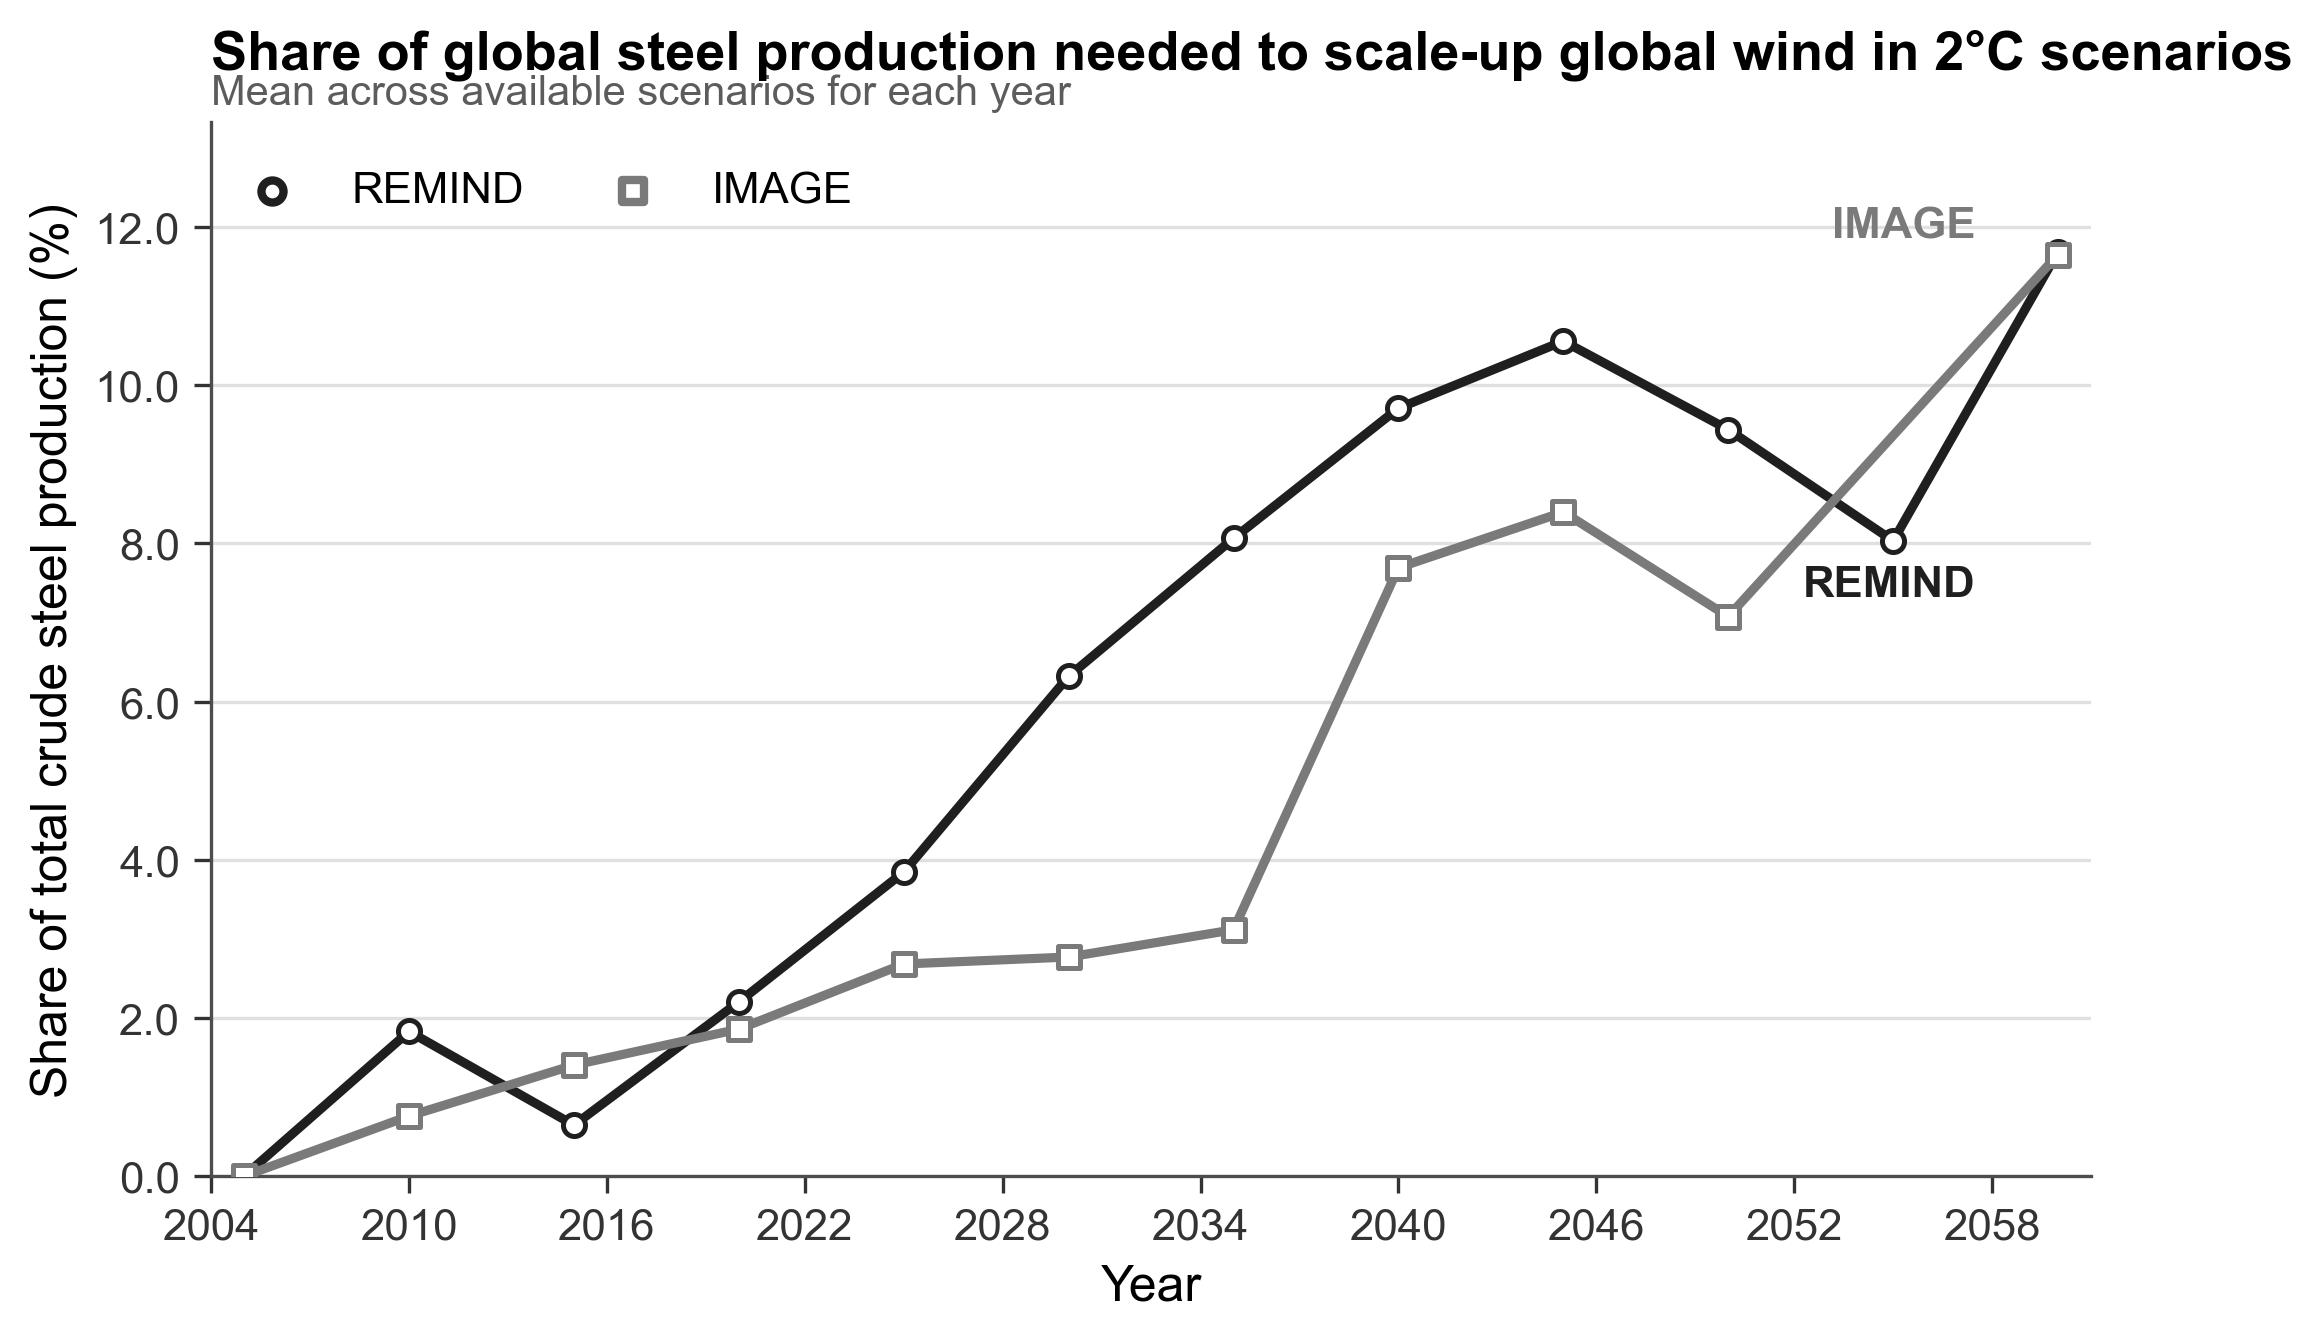

In [8]:
share_col = "Share_wind_steel_of_total_crude_steel_pct"
year_col = "Year"
max_year = 2061

required_cols = [year_col, share_col]

for name, df_ in {
    "df_result_remind": df_result_remind,
    "df_result_image": df_result_image,
}.items():
    missing = [c for c in required_cols if c not in df_.columns]
    if missing:
        raise KeyError(f"{name} is missing required columns: {missing}")

def prepare_series(df, source_name, max_year=2100):
    cols = [c for c in ["Model", "Scenario", year_col, share_col] if c in df.columns]
    tmp = df[cols].copy()

    tmp[year_col] = pd.to_numeric(tmp[year_col], errors="coerce")
    tmp[share_col] = pd.to_numeric(tmp[share_col], errors="coerce")
    tmp = tmp.dropna(subset=[year_col, share_col])

    out = (
        tmp.groupby(year_col, as_index=False)[share_col]
        .mean()
        .sort_values(year_col)
    )

    # keep only years up to 2100
    out = out[out[year_col] <= max_year].copy()

    if out.empty:
        raise ValueError(f"No data left for {source_name} after filtering to years <= {max_year}")

    out["Source"] = source_name
    return out

plot_remind = prepare_series(df_result_remind, "REMIND", max_year=max_year)
plot_image = prepare_series(df_result_image, "IMAGE", max_year=max_year)
plot_df = pd.concat([plot_remind, plot_image], ignore_index=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 10.5,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
})

fig, ax = plt.subplots(figsize=(7.2, 4.6), dpi=300)

series_specs = [
    ("REMIND", plot_remind, "o", "#1f1f1f"),
    ("IMAGE",  plot_image,  "s", "#7a7a7a"),
]

for source, df_src, marker, color in series_specs:
    ax.plot(
        df_src[year_col],
        df_src[share_col],
        lw=2.2,
        color=color,
        solid_capstyle="round",
        zorder=3,
    )
    ax.scatter(
        df_src[year_col],
        df_src[share_col],
        s=28,
        marker=marker,
        facecolor="white",
        edgecolor=color,
        linewidth=1.2,
        zorder=4,
        label=source,
    )

xmin = plot_df[year_col].min()
ymax = plot_df[share_col].max()

ax.set_xlim(xmin - 1, max_year)
ax.set_ylim(0, ymax * 1.14 if ymax > 0 else 1)

ax.set_xlabel("Year")
ax.set_ylabel("Share of total crude steel production (%)")

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}"))

ax.grid(axis="y", color="#d9d9d9", linewidth=0.8, alpha=0.8)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#4d4d4d")
ax.spines["bottom"].set_color("#4d4d4d")
ax.tick_params(axis="both", colors="#333333")

ax.set_title(
    "Share of global steel production needed to scale-up global wind in 2°C scenarios",
    loc="left",
    pad=12.8,
    fontweight="bold"
)

ax.text(
    0.0, 1.01,
    "Mean across available scenarios for each year",
    transform=ax.transAxes,
    ha="left", va="bottom",
    fontsize=10,
    color="#5c5c5c"
)

leg = ax.legend(
    loc="upper left",
    frameon=False,
    ncol=2,
    handlelength=2.0,
    columnspacing=1.5,
    borderaxespad=0.0,
    bbox_to_anchor=(0.0, 0.97),
)

# optional: remove entirely if you prefer cleaner line-end labels only
handles = getattr(leg, "legend_handles", None) or getattr(leg, "legendHandles", [])
for h in handles:
    try:
        h.set_linewidth(2)
    except Exception:
        pass

def add_end_label(df_src, label, color, dx=-2.5, dy=0.0, weight="normal"):
    x = df_src[year_col].iloc[-1]
    y = df_src[share_col].iloc[-1]
    ax.text(
        x + dx, y + dy,
        label,
        color=color,
        fontsize=10.5,
        ha="right",
        va="center",
        fontweight=weight
    )

remind_last = plot_remind[share_col].iloc[-1]
image_last = plot_image[share_col].iloc[-1]
offset = 0.03 * ymax if ymax > 0 else 0.05

if abs(remind_last - image_last) < offset:
    add_end_label(plot_remind, "REMIND", "#1f1f1f", dy=-12 * offset, weight="bold")
    add_end_label(plot_image,  "IMAGE",  "#7a7a7a", dy=+1 * offset, weight="bold")
else:
    add_end_label(plot_remind, "REMIND", "#1f1f1f", weight="bold")
    add_end_label(plot_image,  "IMAGE",  "#7a7a7a", weight="bold")

plt.tight_layout()

fig.savefig("figs/wind_turbines.png", dpi=600, bbox_inches="tight")

plt.show()